In [ ]:
!ls


ml-32m.zip  sample_data


In [ ]:
!unzip ml-32m.zip


Archive:  ml-32m.zip
   creating: ml-32m/
  inflating: ml-32m/tags.csv         
  inflating: ml-32m/links.csv        
  inflating: ml-32m/README.txt       
  inflating: ml-32m/checksums.txt    
  inflating: ml-32m/ratings.csv      
  inflating: ml-32m/movies.csv       


In [ ]:
import pandas as pd
data_path = 'ml-32m/'

movies = pd.read_csv(data_path + 'movies.csv')
ratings = pd.read_csv(data_path + 'ratings.csv')
tags = pd.read_csv(data_path + 'tags.csv')
links = pd.read_csv(data_path + 'links.csv')

print("Movies sample:")
print(movies.head())

print("\nRatings sample:")
print(ratings.head())

print("\nTags sample:")
print(tags.head())

print("\nLinks sample:")
print(links.head())


Movies sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings sample:
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858

Tags sample:
   userId  movieId          tag   timestamp
0      22    26479  Kevin Kline  1583038886
1      22    79592     misogyny  1581476297

In [ ]:

tagged_movies = tags.merge(movies[['movieId', 'title']], on='movieId', how='left')

print(tagged_movies[['tag', 'title']].head(10))


                        tag                            title
0               Kevin Kline  Pirates of Penzance, The (1983)
1                  misogyny           Other Guys, The (2010)
2                acrophobia                  Stowaway (2021)
3                     music               Beetlejuice (1988)
4                     weird               Beetlejuice (1988)
5              Steve Martin                   Roxanne (1987)
6  the killls and the score                    Madman (1981)
7                  bullying                Mean Girls (2004)
8                    clique                Mean Girls (2004)
9             coming of age                Mean Girls (2004)


In [ ]:
import datetime

timestamp = 1583038886
dt_object = datetime.datetime.fromtimestamp(timestamp)
print(dt_object)


2020-03-01 05:01:26


In [ ]:
import pandas as pd

ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['date'] = pd.to_datetime(tags['timestamp'], unit='s')

print(ratings[['timestamp', 'date']].head())
print(tags[['timestamp', 'date']].head())


   timestamp                date
0  944249077 1999-12-03 19:24:37
1  944250228 1999-12-03 19:43:48
2  943230976 1999-11-22 00:36:16
3  944249077 1999-12-03 19:24:37
4  943228858 1999-11-22 00:00:58
    timestamp                date
0  1583038886 2020-03-01 05:01:26
1  1581476297 2020-02-12 02:58:17
2  1622483469 2021-05-31 17:51:09
3  1249808064 2009-08-09 08:54:24
4  1249808102 2009-08-09 08:55:02


In [ ]:

min_ratings = 50


rating_stats = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
rating_stats.columns = ['avg_rating', 'rating_count']


popular_movies = rating_stats[rating_stats['rating_count'] >= min_ratings]


top_movies = popular_movies.sort_values('avg_rating', ascending=False).head(10)


top_movies = top_movies.join(movies.set_index('movieId')['title'])

print(top_movies[['title', 'avg_rating', 'rating_count']])


                                    title  avg_rating  rating_count
movieId                                                            
171011             Planet Earth II (2016)    4.446830          1956
159817                Planet Earth (2006)    4.444369          2948
170705            Band of Brothers (2001)    4.426539          2811
318      Shawshank Redemption, The (1994)    4.404614        102929
171495                             Cosmos    4.330081           615
858                 Godfather, The (1972)    4.317030         66440
202439                    Parasite (2019)    4.312254         11670
179135              Blue Planet II (2017)    4.300086          1163
198185                  Twin Peaks (1989)    4.298684          1140
220528            Twelve Angry Men (1954)    4.286192           449


In [ ]:
top_rated_count = rating_stats.sort_values('rating_count', ascending=False).head(10)
top_rated_count = top_rated_count.join(movies.set_index('movieId')['title'])

print("Top 10 Most Rated Movies:")
print(top_rated_count[['title', 'rating_count', 'avg_rating']])


Top 10 Most Rated Movies:
                                                     title  rating_count  \
movieId                                                                    
318                       Shawshank Redemption, The (1994)        102929   
356                                    Forrest Gump (1994)        100296   
296                                    Pulp Fiction (1994)         98409   
2571                                    Matrix, The (1999)         93808   
593                       Silence of the Lambs, The (1991)         90330   
260              Star Wars: Episode IV - A New Hope (1977)         85010   
2959                                     Fight Club (1999)         77332   
480                                   Jurassic Park (1993)         75233   
527                                Schindler's List (1993)         73849   
4993     Lord of the Rings: The Fellowship of the Ring,...         73122   

         avg_rating  
movieId              
318        4.4046

In [ ]:

movies_expanded = movies.copy()
movies_expanded['genres'] = movies_expanded['genres'].str.split('|')
movies_expanded = movies_expanded.explode('genres')

ratings_genres = ratings.merge(movies_expanded[['movieId', 'genres']], on='movieId')

genre_stats = ratings_genres.groupby('genres').agg({'rating': ['mean', 'count']})
genre_stats.columns = ['avg_rating', 'rating_count']

genre_stats = genre_stats.sort_values('avg_rating', ascending=False)

print("Genre Popularity:")
print(genre_stats.head(10))


Genre Popularity:
             avg_rating  rating_count
genres                               
Film-Noir      3.915774        304710
War            3.791699       1594110
Crime          3.691771       5373051
Documentary    3.691182        427353
Drama          3.682454      13973271
Mystery        3.673103       2615322
Animation      3.615332       2214562
Western        3.600175        596654
IMAX           3.593312       1494179
Musical        3.554277       1159516


In [ ]:
user_activity = ratings.groupby('userId').size().sort_values(ascending=False).head(10)
print("Top 10 Most Active Users (by number of ratings):")
print(user_activity)


Top 10 Most Active Users (by number of ratings):
userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
dtype: int64


In [ ]:
ratings['year'] = ratings['date'].dt.year
yearly_trends = ratings.groupby('year')['rating'].mean()

print("Average Rating by Year:")
print(yearly_trends.tail(10))  # Last 10 years


Average Rating by Year:
year
2014    3.611611
2015    3.559331
2016    3.536441
2017    3.548444
2018    3.570690
2019    3.578934
2020    3.598791
2021    3.582822
2022    3.499670
2023    3.569507
Name: rating, dtype: float64


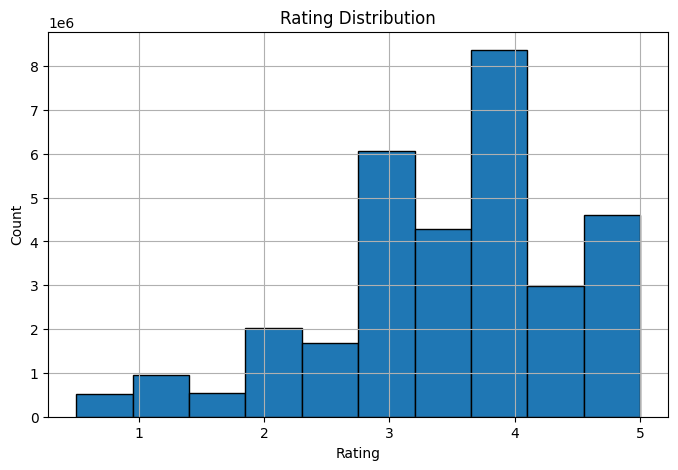

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
ratings['rating'].hist(bins=10, edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


In [ ]:
top_tags = tags['tag'].value_counts().head(15)
print("Top 15 Most Used Tags:")
print(top_tags)


Top 15 Most Used Tags:
tag
sci-fi                10996
atmospheric            9589
action                 8473
comedy                 8139
funny                  7467
surreal                7231
visually appealing     7090
based on a book        6617
twist ending           6521
dark comedy            6053
thought-provoking      6000
dystopia               5646
violence               5389
cinematography         5277
romance                5271
Name: count, dtype: int64


In [ ]:
tag_counts = tags.groupby('movieId').size().sort_values(ascending=False).head(10)
tag_counts = tag_counts.to_frame(name='tag_count').join(movies.set_index('movieId')['title'])

print("Top 10 Movies by Number of Tags:")
print(tag_counts)


Top 10 Movies by Number of Tags:
         tag_count                                         title
movieId                                                         
296           6697                           Pulp Fiction (1994)
79132         6568                              Inception (2010)
260           6519     Star Wars: Episode IV - A New Hope (1977)
2571          5722                            Matrix, The (1999)
2959          5532                             Fight Club (1999)
109487        5477                           Interstellar (2014)
318           4892              Shawshank Redemption, The (1994)
4226          3808                                Memento (2000)
7361          3683  Eternal Sunshine of the Spotless Mind (2004)
356           3581                           Forrest Gump (1994)


In [ ]:
user_rating_mean = ratings.groupby('userId')['rating'].mean()
print("Users with Highest Average Ratings (Top 10):")
print(user_rating_mean.sort_values(ascending=False).head(10))

print("\nUsers with Lowest Average Ratings (Top 10):")
print(user_rating_mean.sort_values(ascending=True).head(10))


Users with Highest Average Ratings (Top 10):
userId
149555    5.0
193038    5.0
69327     5.0
69313     5.0
138685    5.0
88784     5.0
198932    5.0
193281    5.0
68595     5.0
89759     5.0
Name: rating, dtype: float64

Users with Lowest Average Ratings (Top 10):
userId
21106     0.5
112966    0.5
175441    0.5
136397    0.5
64896     0.5
56314     0.5
69215     0.5
97508     0.5
160861    0.5
135854    0.5
Name: rating, dtype: float64


In [ ]:
import pandas as pd
from datetime import timedelta

# Step 1: Extract release year from the movie title
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# Step 2: Create a 'release_date' assuming January 1 of release year (since we lack exact dates)
movies['release_date'] = pd.to_datetime(movies['release_year'], format='%Y')

# Step 3: Join ratings with movies to get release_date for each rating
ratings_with_release = ratings.merge(movies[['movieId', 'release_date']], on='movieId', how='left')

# Step 4: Calculate time difference between rating date and release date
ratings_with_release['days_since_release'] = (ratings_with_release['date'] - ratings_with_release['release_date']).dt.days

# Step 5: Filter ratings within 30 days after release
first_month_ratings = ratings_with_release[
    (ratings_with_release['days_since_release'] >= 0) &
    (ratings_with_release['days_since_release'] <= 30)
]

# Step 6: Calculate average rating for each movie within first month
first_month_avg = first_month_ratings.groupby('movieId')['rating'].mean()

# Step 7: Join with movie titles for clarity
first_month_avg = first_month_avg.to_frame(name='avg_first_month_rating').join(movies.set_index('movieId')['title'])

# Step 8: Show top 10 new releases by average rating in the first month (with some minimum rating counts)
rating_counts = first_month_ratings.groupby('movieId').size()
popular_new_releases = first_month_avg[rating_counts >= 10].sort_values('avg_first_month_rating', ascending=False).head(10)

print(popular_new_releases[['title', 'avg_first_month_rating']])


                                                     title  \
movieId                                                      
122914             Avengers: Infinity War - Part II (2019)   
168266                            T2: Trainspotting (2017)   
5064                      The Count of Monte Cristo (2002)   
1166                                 Farmer & Chase (1997)   
210861                                The Gentlemen (2020)   
42730                                    Glory Road (2006)   
7254                           The Butterfly Effect (2004)   
197529                                   The Upside (2019)   
231057                                      The Dig (2021)   
196417   How to Train Your Dragon: The Hidden World (2019)   

         avg_first_month_rating  
movieId                          
122914                 4.227273  
168266                 4.050000  
5064                   4.032258  
1166                   4.000000  
210861                 3.928571  
42730            